# BTBP-family extractant generation for Am(III)/Eu(III) separation

Self-contained reproduction of the design and evaluation workflow.

**Task.** Propose novel solvent-extraction ligands that carry Am(III) into the organic phase
while leaving Eu(III) in the aqueous phase, structurally anchored on the
bis-triazinyl-bipyridine (BTBP) class.

**Acceptance criteria, each checked numerically below**

| # | Criterion | Test |
|---|---|---|
| 1 | Target metal Am(III) to ORGANIC | tetradentate N-donor chelate retained (ring census) |
| 2 | Other metal Eu(III) to AQUEOUS | same soft-N-donor motif; design intent, not measured |
| 3 | Tanimoto vs *Experimental* within 0.25-0.85 | ECFP4 (Morgan r=2, 2048 bit) |
| 4 | Tanimoto vs *LLM generated* below 0.85 | internal pairwise maxima |
| 5 | LogP to ORGANIC, value above 3 | Crippen `MolLogP` |

Requires `rdkit`, `pandas`, `pillow`.

In [1]:
import itertools, json, os, sys

import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import (AllChem, Crippen, Descriptors, Draw,
                        rdFingerprintGenerator, rdMolDescriptors, RDConfig)

sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer  # synthetic accessibility, Ertl & Schuffenhauer 2009

RDLogger.DisableLog("rdApp.*")
print("rdkit", Chem.rdBase.rdkitVersion)

rdkit 2026.03.4


## 1. Reference set

The `Source = Experimental` rows of the SMILES Evaluation Status Table, embedded verbatim so the
notebook runs without external files. These are the known-active ligands the designs learn from:
CyMe4-BTBP and CyMe4-BTPhen, camphor-fused BTP/BTBP, n-propyl and n-pentyl BTP/BTBP, a branched
diglycolamide, and a bis-pyrazolyl-pyridine.

In [2]:
EXPERIMENTAL_TABLE = json.loads(r'''
[
  {
    "SMILES": "CC12CCC(c3nnc(-c4cccc(-c5nnc6c(n5)C5(C)CCC6C5(C)C)n4)nc31)C2(C)C",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CC(C)(C)c1cc(-c2cc(C(C)(C)C)cc(-c3nnc4c(n3)C(C)(C)CCC4(C)C)n2)nc(-c2nnc3c(n2)C(C)(C)CCC3(C)C)c1",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CC12CCC(c3nnc(-c4cccc(-c5cccc(-c6nnc7c(n6)C6(C)CCC7C6(C)C)n5)n4)nc31)C2(C)C",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CCCc1nnc(-c2cccc(-c3nnc(CCC)c(CCC)n3)n2)nc1CCC",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CC1(C)CCC(C)(C)c2nc(-c3cccc(-c4cccc(-c5nnc6c(n5)C(C)(C)CCC6(C)C)n4)n3)nnc21",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "Cc1cc(-c2cc(C)cc(-c3nnc4c(n3)C(C)(C)CCC4(C)C)n2)nc(-c2nnc3c(n2)C(C)(C)CCC3(C)C)c1",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CCCCCc1nnc(-c2cccc(-c3cccc(-c4nnc(CCCCC)c(CCCCC)n4)n3)n2)nc1CCCCC",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CCCCC(CC)CN(CC(=O)N(CC(CC)CCCC)CC(CC)CCCC)CC(=O)N(CC(CC)CCCC)CC(CC)CCCC",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  },
  {
    "SMILES": "CC(C)(C)Cc1cc(-c2cccc(-c3cc(CC(C)(C)C)[nH]n3)n2)n[nH]1",
    "Target_metal": "ORGANIC",
    "Other_metal": "AQUEOUS",
    "Source": "Experimental",
    "Similarity_to_Experimental": "Reference",
    "Similarity_to_Generated": "Reference",
    "LogP": "ORGANIC"
  }
]
''')

exp_df = pd.DataFrame(EXPERIMENTAL_TABLE)
exp_smiles = exp_df["SMILES"].tolist()
exp_mols = [Chem.MolFromSmiles(s) for s in exp_smiles]
assert all(m is not None for m in exp_mols), "reference set contains unparseable SMILES"
exp_df[["SMILES", "Source", "Target_metal", "Other_metal", "LogP"]]

,SMILES,Source,Target_metal,Other_metal,LogP
0,CC12CCC(c3nnc(-c4cccc(-c5nnc6c(n5)C5(C)CCC6C5(C)C)n4)nc31)C2(C)C,Experimental,ORGANIC,AQUEOUS,ORGANIC
1,CC(C)(C)c1cc(-c2cc(C(C)(C)C)cc(-c3nnc4c(n3)C(C)(C)CCC4(C)C)n2)nc(-c2nnc3c(n2)C(C)(C)CCC3(C)C)c1,Experimental,ORGANIC,AQUEOUS,ORGANIC
2,CC12CCC(c3nnc(-c4cccc(-c5cccc(-c6nnc7c(n6)C6(C)CCC7C6(C)C)n5)n4)nc31)C2(C)C,Experimental,ORGANIC,AQUEOUS,ORGANIC
3,CCCc1nnc(-c2cccc(-c3nnc(CCC)c(CCC)n3)n2)nc1CCC,Experimental,ORGANIC,AQUEOUS,ORGANIC
4,CC1(C)CCC(C)(C)c2nc(-c3cccc(-c4cccc(-c5nnc6c(n5)C(C)(C)CCC6(C)C)n4)n3)nnc21,Experimental,ORGANIC,AQUEOUS,ORGANIC
5,Cc1cc(-c2cc(C)cc(-c3nnc4c(n3)C(C)(C)CCC4(C)C)n2)nc(-c2nnc3c(n2)C(C)(C)CCC3(C)C)c1,Experimental,ORGANIC,AQUEOUS,ORGANIC
6,CCCCCc1nnc(-c2cccc(-c3cccc(-c4nnc(CCCCC)c(CCCCC)n4)n3)n2)nc1CCCCC,Experimental,ORGANIC,AQUEOUS,ORGANIC
7,CCCCC(CC)CN(CC(=O)N(CC(CC)CCCC)CC(CC)CCCC)CC(=O)N(CC(CC)CCCC)CC(CC)CCCC,Experimental,ORGANIC,AQUEOUS,ORGANIC
8,CC(C)(C)Cc1cc(-c2cccc(-c3cc(CC(C)(C)C)[nH]n3)n2)n[nH]1,Experimental,ORGANIC,AQUEOUS,ORGANIC


In [3]:
# Descriptor envelope of the reference ligands: the region the new designs should land near.
exp_profile = pd.DataFrame({
    "MW": [round(Descriptors.MolWt(m), 1) for m in exp_mols],
    "MolLogP": [round(Crippen.MolLogP(m), 2) for m in exp_mols],
    "arom_N": [sum(1 for a in m.GetAtoms() if a.GetSymbol() == "N" and a.GetIsAromatic())
               for m in exp_mols],
    "SA_score": [round(sascorer.calculateScore(m), 2) for m in exp_mols],
})
exp_profile.describe().loc[["min", "mean", "max"]].round(2)

,MW,MolLogP,arom_N,SA_score
min,351.50,4.60,0.00,2.94
mean,530.32,7.18,6.56,3.85
max,692.20,12.03,8.00,5.47


## 2. Candidate designs

Three levers are varied independently, which spreads the set while keeping every member inside the
BTBP class:

1. **Backbone rigidity.** 1,10-phenanthroline replaces 2,2'-bipyridine in several designs
   (BTPhen-type), preorganising the N4 cavity and removing the rotation about the inter-ring bond
   that a bipyridine must freeze out on complexation. One 4-*tert*-butylpyridine BTP backbone is
   included as a tridentate outlier for scaffold spread.
2. **Radiolytic and acid hardening.** Every triazine alpha-carbon is fully substituted
   (gem-dimethyl, gem-diethyl, spirocyclohexyl, *tert*-butyl, or aryl). This removes the benzylic
   C-H sites responsible for degradation of n-alkyl BTPs in nitric acid and under radiolysis; the
   n-propyl and n-pentyl reference entries have exactly those vulnerable positions.
3. **Lipophilicity.** Branched and spiro aliphatic caps, plus 5,5'-di-n-hexyl backbone
   substitution, raise LogP without introducing ionizable or hydrolyzable groups. No esters,
   amides, or phosphoryl functions appear, so the ligands stay neutral N-donors whose Am(III)
   preference comes from softer covalent bonding rather than from pH-sensitive sites.

In [4]:
CANDIDATES = {
    # phenanthroline backbone (preorganised) with CyMe4 triazine caps
    "CyMe4-BTPhen":
        "CC1(C)CCC(C)(C)c2nc(-c3ccc4ccc5ccc(-c6nnc7c(n6)C(C)(C)CCC7(C)C)nc5c4n3)nnc21",
    # camphor-fused triazine on phenanthroline
    "Camphor-BTPhen":
        "CC12CCC(c3nnc(-c4ccc5ccc6ccc(-c7nnc8c(n7)C9(C)CCC8C9(C)C)nc6c5n4)nc31)C2(C)C",
    # tetraethyl analogue of the CyMe4 cap on bipyridine
    "TEtCy-BTBP":
        "CCC1(CC)CCC(CC)(CC)c2nc(-c3cccc(-c4cccc(-c5nnc6c(n5)C(CC)(CC)CCC6(CC)CC)n4)n3)nnc21",
    # 5,8-dispiro(cyclohexane) triazine on bipyridine
    "Dispiro-BTBP":
        "C12(CCCCC2)CCC3(CCCCC3)c4nc(-c5cccc(-c6cccc(-c7nnc8c(n7)C9(CCCCC9)CCC8%10CCCCC%10)n6)n5)nnc41",
    # 5,6-di-tert-butyl triazine: no alpha C-H whatsoever
    "diTBu-BTBP":
        "CC(C)(C)c1nnc(-c2cccc(-c3cccc(-c4nnc(C(C)(C)C)c(C(C)(C)C)n4)n3)n2)nc1C(C)(C)C",
    # fully aromatic triazine side arms
    "BisArTBu-BTBP":
        "CC(C)(C)c1ccc(-c2nnc(-c3cccc(-c4cccc(-c5nnc(-c6ccc(C(C)(C)C)cc6)c(-c6ccc(C(C)(C)C)cc6)n5)n4)n3)nc2-c2ccc(C(C)(C)C)cc2)cc1",
    # CyMe4 triazine on 4,7-diphenyl-1,10-phenanthroline (bathophenanthroline)
    "CyMe4-BathoBTPhen":
        "CC1(C)CCC(C)(C)c2nc(-c3cc(-c4ccccc4)c5ccc6c(-c7ccccc7)cc(-c8nnc9c(n8)C(C)(C)CCC9(C)C)nc6c5n3)nnc21",
    # lipophilicity tuned on the backbone rather than on the caps
    "CyMe4-diHexylBTBP":
        "CC1(C)CCC(C)(C)c2nc(-c3c(CCCCCC)ccc(-c4ccc(CCCCCC)c(-c5nnc6c(n5)C(C)(C)CCC6(C)C)n4)n3)nnc21",
    "Dispiro-BTPhen":
        "C12(CCCCC2)CCC3(CCCCC3)c4nc(-c5ccc6ccc7ccc(-c8nnc9c(n8)C%11(CCCCC%11)CCC9%12CCCCC%12)nc7c6n5)nnc41",
    # tridentate BTP backbone, included for scaffold spread
    "TEtCy-tBuBTP":
        "CCC1(CC)CCC(CC)(CC)c2nc(-c3cc(C(C)(C)C)cc(-c4nnc5c(n4)C(CC)(CC)CCC5(CC)CC)n3)nnc21",
}

invalid = [k for k, v in CANDIDATES.items() if Chem.MolFromSmiles(v) is None]
assert not invalid, f"unparseable SMILES: {invalid}"
print(f"{len(CANDIDATES)} candidates, all parse")

10 candidates, all parse


## 3. Structural check: is the chelate still there?

An(III)/Ln(III) discrimination in this family comes from the soft-N-donor pocket, two 1,2,4-triazine
rings flanking a bipyridine or phenanthroline core. Rather than trusting the drawing, count aromatic
six-membered rings by nitrogen content. A design that lost a triazine during editing would still be
a valid molecule and would still pass the LogP and similarity filters, so this check is what stops a
structurally broken candidate from reaching the output list.

In [5]:
def ring_census(mol):
    """Count aromatic 6-rings holding 3 N (1,2,4-triazine) and 1 N (pyridine-type)."""
    triazine = pyridine = 0
    for ring in mol.GetRingInfo().AtomRings():
        atoms = [mol.GetAtomWithIdx(i) for i in ring]
        if len(ring) == 6 and all(a.GetIsAromatic() for a in atoms):
            n_nitrogen = sum(1 for a in atoms if a.GetSymbol() == "N")
            if n_nitrogen == 3:
                triazine += 1
            elif n_nitrogen == 1:
                pyridine += 1
    return triazine, pyridine


# sanity: CyMe4-BTBP from the reference set must read as 2 triazines + 2 pyridines
assert ring_census(Chem.MolFromSmiles(exp_smiles[4])) == (2, 2)
print("ring_census validated on the CyMe4-BTBP reference")

ring_census validated on the CyMe4-BTBP reference


## 4. Fingerprints, similarity, and physicochemical scoring

ECFP4 is generated as Morgan fingerprints of radius 2 over 2048 bits; similarity is Tanimoto.
Criterion 3 uses the *maximum* similarity across the experimental entries, since the nearest
neighbour is what decides whether a molecule reads as derivative or as novel.

In [6]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

exp_fps = [fpgen.GetFingerprint(m) for m in exp_mols]
exp_inchikeys = {Chem.MolToInchiKey(m) for m in exp_mols}

records = []
for name, smiles in CANDIDATES.items():
    mol = Chem.MolFromSmiles(smiles)
    fp = fpgen.GetFingerprint(mol)
    sims = [DataStructs.TanimotoSimilarity(fp, ref) for ref in exp_fps]
    n_triazine, n_pyridine = ring_census(mol)
    records.append({
        "name": name,
        "canonical_smiles": Chem.MolToSmiles(mol),
        "formula": rdMolDescriptors.CalcMolFormula(mol),
        "MW": round(Descriptors.MolWt(mol), 1),
        "MolLogP": round(Crippen.MolLogP(mol), 2),
        "TPSA": round(rdMolDescriptors.CalcTPSA(mol), 1),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "arom_N": sum(1 for a in mol.GetAtoms()
                      if a.GetSymbol() == "N" and a.GetIsAromatic()),
        "n_triazine_rings": n_triazine,
        "n_pyridine_rings": n_pyridine,
        "rot_bonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "SA_score": round(sascorer.calculateScore(mol), 2),
        "max_sim_exp": round(max(sims), 3),
        "min_sim_exp": round(min(sims), 3),
        "dup_of_exp": Chem.MolToInchiKey(mol) in exp_inchikeys,
    })

df = pd.DataFrame(records)
df[["name", "formula", "MW", "MolLogP", "n_triazine_rings",
    "n_pyridine_rings", "SA_score", "max_sim_exp"]]

,name,formula,MW,MolLogP,n_triazine_rings,n_pyridine_rings,SA_score,max_sim_exp
0,CyMe4-BTPhen,C34H38N8,558.7,7.19,2,2,3.46,0.686
1,Camphor-BTPhen,C34H34N8,554.7,6.84,2,2,5.52,0.762
2,TEtCy-BTBP,C40H54N8,646.9,9.67,2,2,3.90,0.605
3,Dispiro-BTBP,C44H54N8,695.0,10.24,2,2,4.53,0.622
4,diTBu-BTBP,C32H42N8,538.7,7.04,2,2,3.03,0.447
5,BisArTBu-BTBP,C56H58N8,843.1,13.71,2,2,3.03,0.386
6,CyMe4-BathoBTPhen,C46H46N8,710.9,10.52,2,2,3.54,0.558
7,CyMe4-diHexylBTBP,C44H62N8,703.0,10.79,2,2,3.78,0.489
8,Dispiro-BTPhen,C46H54N8,719.0,10.88,2,2,4.61,0.419
9,TEtCy-tBuBTP,C39H59N7,626.0,9.90,2,1,4.08,0.619


In [7]:
# Criterion 4 operates within the generated set: no two designs may be near-duplicates.
cand_fps = [fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in CANDIDATES.values()]
names = list(CANDIDATES)

df["max_sim_internal"] = [
    max(round(DataStructs.TanimotoSimilarity(cand_fps[i], cand_fps[j]), 3)
        for j in range(len(cand_fps)) if j != i)
    for i in range(len(cand_fps))
]

pairs = sorted(
    ((names[i], names[j], round(DataStructs.TanimotoSimilarity(cand_fps[i], cand_fps[j]), 3))
     for i, j in itertools.combinations(range(len(cand_fps)), 2)),
    key=lambda t: -t[2],
)
pd.DataFrame(pairs[:5], columns=["design_A", "design_B", "tanimoto"])

,design_A,design_B,tanimoto
0,Dispiro-BTBP,Dispiro-BTPhen,0.703
1,TEtCy-BTBP,TEtCy-tBuBTP,0.634
2,CyMe4-BTPhen,Dispiro-BTPhen,0.632
3,CyMe4-BTPhen,CyMe4-BathoBTPhen,0.581
4,CyMe4-BTPhen,Camphor-BTPhen,0.545


## 5. Criterion gate

Each criterion is asserted rather than merely reported, so the notebook fails loudly if an edit to
the candidate list breaks one.

In [8]:
df["crit_chelate"]      = (df.n_triazine_rings == 2) & (df.n_pyridine_rings >= 1)
df["crit_novel"]        = ~df.dup_of_exp
df["crit_sim_exp"]      = df.max_sim_exp.between(0.25, 0.85)
df["crit_sim_internal"] = df.max_sim_internal < 0.85
df["crit_logP"]         = df.MolLogP > 3.0

gate = ["crit_chelate", "crit_novel", "crit_sim_exp", "crit_sim_internal", "crit_logP"]
df["PASS"] = df[gate].all(axis=1)

for col in gate:
    failures = df.loc[~df[col], "name"].tolist()
    assert not failures, f"{col} failed for {failures}"

print(f"{int(df.PASS.sum())} / {len(df)} designs satisfy all criteria")
print(f"cLogP range        {df.MolLogP.min():.2f} - {df.MolLogP.max():.2f}   (threshold > 3)")
print(f"Tc vs experimental {df.max_sim_exp.min():.3f} - {df.max_sim_exp.max():.3f}   (window 0.25 - 0.85)")
print(f"Tc internal max    {df.max_sim_internal.max():.3f}   (ceiling 0.85)")
df[["name", "MolLogP", "max_sim_exp", "max_sim_internal", "PASS"]]

10 / 10 designs satisfy all criteria
cLogP range        6.84 - 13.71   (threshold > 3)
Tc vs experimental 0.386 - 0.762   (window 0.25 - 0.85)
Tc internal max    0.703   (ceiling 0.85)


,name,MolLogP,max_sim_exp,max_sim_internal,PASS
0,CyMe4-BTPhen,7.19,0.686,0.632,True
1,Camphor-BTPhen,6.84,0.762,0.545,True
2,TEtCy-BTBP,9.67,0.605,0.634,True
3,Dispiro-BTBP,10.24,0.622,0.703,True
4,diTBu-BTBP,7.04,0.447,0.526,True
5,BisArTBu-BTBP,13.71,0.386,0.526,True
6,CyMe4-BathoBTPhen,10.52,0.558,0.581,True
7,CyMe4-diHexylBTBP,10.79,0.489,0.479,True
8,Dispiro-BTPhen,10.88,0.419,0.703,True
9,TEtCy-tBuBTP,9.90,0.619,0.634,True


## 6. Structures

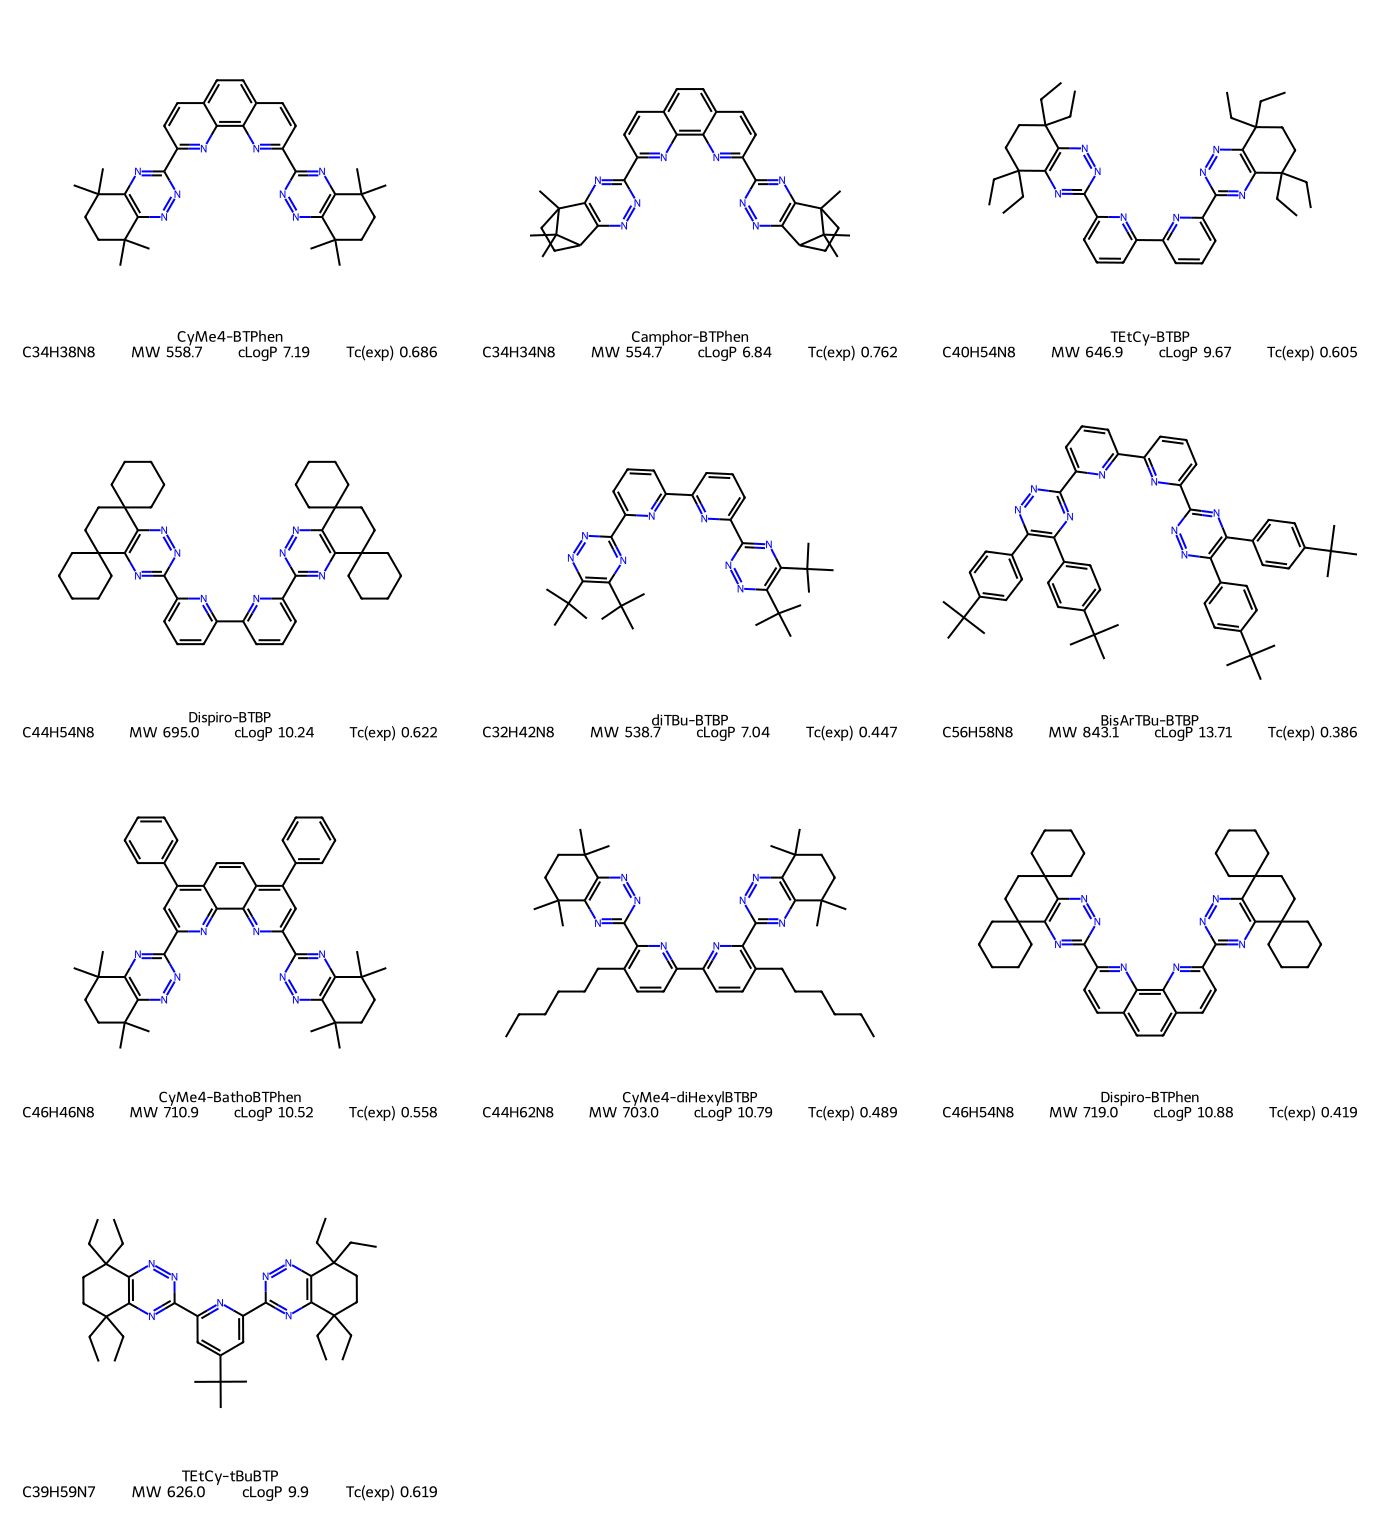

In [9]:
mols = [Chem.MolFromSmiles(s) for s in CANDIDATES.values()]
for m in mols:
    AllChem.Compute2DCoords(m)

legends = [
    f"{r['name']}\n{r.formula} · MW {r.MW} · cLogP {r.MolLogP} · Tc(exp) {r.max_sim_exp}"
    for _, r in df.iterrows()
]

grid = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(460, 380),
                            legends=legends, useSVG=False, returnPNG=False)
grid.save("btbp_candidates.png")
grid

## 7. Export

Writes the full scoring table plus the evaluation-table rows for the ten designs, ready to append to
the SMILES Evaluation Status Table.

In [10]:
df.to_csv("btbp_candidate_scores.csv", index=False)

generated = [
    {
        "SMILES": r.canonical_smiles,
        "design_name": r["name"],
        "Target_metal": "ORGANIC",
        "Other_metal": "AQUEOUS",
        "Source": "LLM generated",
        "LogP": "ORGANIC",
        "MolLogP": r.MolLogP,
        "Similarity_to_Experimental": r.max_sim_exp,
    }
    for _, r in df.iterrows()
]
with open("generated_smiles.json", "w") as fh:
    json.dump(generated, fh, indent=2)

print(json.dumps([g["SMILES"] for g in generated], indent=1))

[
 "CC1(C)CCC(C)(C)c2nc(-c3ccc4ccc5ccc(-c6nnc7c(n6)C(C)(C)CCC7(C)C)nc5c4n3)nnc21",
 "CC12CCC(c3nnc(-c4ccc5ccc6ccc(-c7nnc8c(n7)C7(C)CCC8C7(C)C)nc6c5n4)nc31)C2(C)C",
 "CCC1(CC)CCC(CC)(CC)c2nc(-c3cccc(-c4cccc(-c5nnc6c(n5)C(CC)(CC)CCC6(CC)CC)n4)n3)nnc21",
 "c1cc(-c2cccc(-c3nnc4c(n3)C3(CCCCC3)CCC43CCCCC3)n2)nc(-c2nnc3c(n2)C2(CCCCC2)CCC32CCCCC2)c1",
 "CC(C)(C)c1nnc(-c2cccc(-c3cccc(-c4nnc(C(C)(C)C)c(C(C)(C)C)n4)n3)n2)nc1C(C)(C)C",
 "CC(C)(C)c1ccc(-c2nnc(-c3cccc(-c4cccc(-c5nnc(-c6ccc(C(C)(C)C)cc6)c(-c6ccc(C(C)(C)C)cc6)n5)n4)n3)nc2-c2ccc(C(C)(C)C)cc2)cc1",
 "CC1(C)CCC(C)(C)c2nc(-c3cc(-c4ccccc4)c4ccc5c(-c6ccccc6)cc(-c6nnc7c(n6)C(C)(C)CCC7(C)C)nc5c4n3)nnc21",
 "CCCCCCc1ccc(-c2ccc(CCCCCC)c(-c3nnc4c(n3)C(C)(C)CCC4(C)C)n2)nc1-c1nnc2c(n1)C(C)(C)CCC2(C)C",
 "c1cc2ccc3ccc(-c4nnc5c(n4)C4(CCCCC4)CCC54CCCCC4)nc3c2nc1-c1nnc2c(n1)C1(CCCCC1)CCC21CCCCC1",
 "CCC1(CC)CCC(CC)(CC)c2nc(-c3cc(C(C)(C)C)cc(-c4nnc5c(n4)C(CC)(CC)CCC5(CC)CC)n3)nnc21"
]


## 8. Synthetic route note

All ten follow the established BTBP condensation: a pyridine-2,6- or 2,2'-bipyridine-6,6'- or
1,10-phenanthroline-2,9-dicarbohydrazide (or the dicarbonitrile via the amidrazone) condensed with
the matching alpha-diketone, then oxidative aromatisation.

| Design family | alpha-diketone required |
|---|---|
| CyMe4 caps | 3,3,6,6-tetramethylcyclohexane-1,2-dione |
| TEtCy caps | 3,3,6,6-tetraethylcyclohexane-1,2-dione |
| Dispiro caps | 3,3:6,6-dispiro(cyclohexane)cyclohexane-1,2-dione |
| Camphor caps | camphorquinone |
| diTBu | 2,2,5,5-tetramethylhexane-3,4-dione |
| BisArTBu | 4,4'-di-tert-butylbenzil |

RDKit SA scores for the set fall in the 3.0-5.5 band on the 1-10 scale, comparable to the
experimental references, so none of these demands unusual chemistry.

## Caveat

`MolLogP` is a Crippen group-contribution estimate, and the `ORGANIC` / `AQUEOUS` metal labels are
design intent inferred from the experimental analogues. They are **not** measured distribution
coefficients. Confirming D(Am), D(Eu), and the separation factor requires the extraction experiments
themselves, or a property model trained on measured partitioning data.